# Hybrid Gibbs simulation analysis

This notebook reads the simulated PsyNet export directly from `../simulated_data.zip` and checks the participant mix, trial completion, and response metadata for the 50% mock-AI validation run.

In [1]:
from collections import Counter
from pathlib import Path
import csv
import io
import json
import zipfile

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams["figure.dpi"] = 50
ZIP_PATH = Path("..") / "simulated_data.zip"
assert ZIP_PATH.exists(), ZIP_PATH

def read_csv(name):
    with zipfile.ZipFile(ZIP_PATH) as zf:
        with zf.open(f"simulated_data/regular/data/{name}.csv") as f:
            return list(csv.DictReader(io.TextIOWrapper(f)))

bots = read_csv("Bot")
trials = read_csv("CustomTrial")
responses = read_csv("Response")
configs = read_csv("ExperimentConfig")
print(f"Loaded {len(bots)} bots, {len(trials)} trials, {len(responses)} responses.")

Loaded 8 bots, 56 trials, 104 responses.


In [2]:
controller_counts = Counter(row["controller"] or "missing" for row in bots)
profile_counts = Counter(row["ai_profile"] or "none" for row in bots)
group_counts = Counter(row["participant_group"] for row in bots)

def markdown_table(title, counts):
    rows = "\n".join(f"| {key} | {value} |" for key, value in sorted(counts.items()))
    display(Markdown(f"### {title}\n\n| Category | Count |\n|---|---:|\n{rows}"))

markdown_table("Controller distribution", controller_counts)
markdown_table("AI profile distribution", profile_counts)
markdown_table("Participant group distribution", group_counts)

### Controller distribution

| Category | Count |
|---|---:|
| ai | 4 |
| human | 4 |

### AI profile distribution

| Category | Count |
|---|---:|
| mock_openrouter | 4 |
| none | 4 |

### Participant group distribution

| Category | Count |
|---|---:|
| A | 4 |
| B | 4 |

In [3]:
trial_summary = {
    "total_trials": len(trials),
    "finalized_trials": sum(row["finalized"] == "True" for row in trials),
    "repeat_trials": sum(row["is_repeat_trial"] == "True" for row in trials),
    "normal_trials": sum(row["is_repeat_trial"] == "False" for row in trials),
}
rows = "\n".join(f"| {key} | {value} |" for key, value in trial_summary.items())
display(Markdown(f"### Trial completion summary\n\n| Metric | Value |\n|---|---:|\n{rows}"))

assert controller_counts == {"ai": 4, "human": 4}
assert profile_counts["mock_openrouter"] == 4
assert trial_summary["total_trials"] == 56
assert trial_summary["finalized_trials"] == 56

### Trial completion summary

| Metric | Value |
|---|---:|
| total_trials | 56 |
| finalized_trials | 56 |
| repeat_trials | 24 |
| normal_trials | 32 |

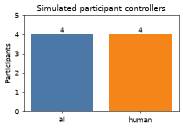

In [4]:
fig, ax = plt.subplots(figsize=(4, 2.5))
labels = list(controller_counts.keys())
values = [controller_counts[label] for label in labels]
ax.bar(labels, values, color=["#4c78a8", "#f58518"][: len(labels)])
ax.set_title("Simulated participant controllers")
ax.set_ylabel("Participants")
ax.set_ylim(0, max(values) + 1)
for index, value in enumerate(values):
    ax.text(index, value + 0.1, str(value), ha="center")
plt.show()

In [5]:
response_metadata = [json.loads(row["metadata_"] or "{}") for row in responses]
ai_response_metadata = [meta for meta in response_metadata if meta.get("controller") == "ai"]
human_response_metadata = [meta for meta in response_metadata if meta.get("controller") == "human"]
summary = {
    "ai_slider_responses_with_metadata": len(ai_response_metadata),
    "human_slider_responses_with_metadata": len(human_response_metadata),
    "mock_parser_statuses": sorted({meta.get("parser_status") for meta in ai_response_metadata}),
}
rows = "\n".join(f"| {key} | {value} |" for key, value in summary.items())
display(Markdown(f"### Slider response metadata\n\n| Metric | Value |\n|---|---|\n{rows}"))
assert summary["ai_slider_responses_with_metadata"] > 0
assert summary["mock_parser_statuses"] == ["mock"]

### Slider response metadata

| Metric | Value |
|---|---|
| ai_slider_responses_with_metadata | 28 |
| human_slider_responses_with_metadata | 28 |
| mock_parser_statuses | ['mock'] |

## Interpretation

The simulated export contains the intended 50/50 controller mix (`4` mock-AI and `4` simulated-human participants). All `56` Gibbs trials were finalized, matching eight participants each completing four normal trials and three repeat trials. AI slider responses carry mock OpenRouter metadata with parser status `mock`, while human-simulated slider responses remain labeled as simulated human behavior. These checks validate workflow and data-path plumbing; they do not claim real OpenRouter model behavior or human behavioral validity.